# 04 Canonical Damaged-Image Generation

This notebook creates the canonical damaged-image dataset by applying the binary masks generated in Notebook 03 to the processed clean paintings from Notebook 02.

For every mask case, the notebook:

1. loads the corresponding clean painting and binary mask;
2. replaces masked pixels with the configured damage-fill colour;
3. preserves all unmasked pixels exactly;
4. saves one damaged RGB PNG image;
5. records clean-image, mask, and damaged-image provenance;
6. records checksums, dimensions, format, fill strategy, and damaged-area statistics;
7. reloads and validates all saved outputs;
8. audits missing, duplicate, stale, and orphaned files;
9. exports canonical metadata, audit tables, figures, and reporting manifests.

The binary mask remains the authoritative definition of the damaged and restoration region.

This notebook performs only synthetic damage creation. Restoration begins in Notebook 05 with the OpenCV Telea baseline.

In [1]:
from pathlib import Path
import sys
import yaml

PROJECT_ROOT = Path.cwd().resolve()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"
CONFIG_PATH = PROJECT_ROOT / "config" / "experiment_50_config.yaml"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

print("Project root:", PROJECT_ROOT)
print("Source directory:", SRC_DIR)
print("Configuration path:", CONFIG_PATH)

if not PROJECT_ROOT.exists():
    raise FileNotFoundError(
        f"Project root does not exist: {PROJECT_ROOT}"
    )

if not SRC_DIR.exists():
    raise FileNotFoundError(
        f"Source directory does not exist: {SRC_DIR}"
    )

if not CONFIG_PATH.exists():
    raise FileNotFoundError(
        f"Experiment configuration does not exist: {CONFIG_PATH}"
    )

print("\nEnvironment gate passed.")

Project root: D:\Masters\FH\Thesis\painting-restoration-eval
Source directory: D:\Masters\FH\Thesis\painting-restoration-eval\src
Configuration path: D:\Masters\FH\Thesis\painting-restoration-eval\config\experiment_50_config.yaml

Environment gate passed.


In [2]:
import json
import shutil
from datetime import datetime, timezone

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image

from restoration_eval.damage import (
    DEFAULT_DAMAGE_FILL_COLOR,
    DEFAULT_DAMAGE_FILL_STRATEGY,
    GENERATOR_NAME,
    GENERATOR_VERSION,
    SUPPORTED_DAMAGE_FILL_STRATEGIES,
    audit_damaged_inventory,
    create_damaged_images_for_dataset,
    validate_damage_application,
    validate_damaged_images,
)

with CONFIG_PATH.open("r", encoding="utf-8") as config_file:
    config = yaml.safe_load(config_file)

paths_cfg = config.get("paths", {})
experiment_cfg = config.get("experiment", {})
preprocessing_cfg = config.get("preprocessing", {})

required_path_keys = [
    "processed_metadata_dir",
    "clean_dir",
    "masked_dir",
    "metrics_dir",
    "figures_dir",
    "reports_dir",
]

missing_path_keys = [
    key
    for key in required_path_keys
    if not paths_cfg.get(key)
]

if missing_path_keys:
    raise ValueError(
        "Configuration is missing required path keys: "
        f"{missing_path_keys}"
    )

processed_metadata_dir = (
    PROJECT_ROOT / paths_cfg["processed_metadata_dir"]
)

processed_metadata_path = (
    processed_metadata_dir
    / "metadata_processed_clean.csv"
)

mask_metadata_path = (
    processed_metadata_dir
    / "metadata_masks.csv"
)

damaged_metadata_path = (
    processed_metadata_dir
    / "metadata_damaged_images.csv"
)

clean_dir = (
    PROJECT_ROOT / paths_cfg["clean_dir"]
)

damaged_dir = (
    PROJECT_ROOT / paths_cfg["masked_dir"]
)

metrics_dir = (
    PROJECT_ROOT / paths_cfg["metrics_dir"]
)

figures_dir = (
    PROJECT_ROOT / paths_cfg["figures_dir"]
    / "damage_creation"
)

reports_dir = (
    PROJECT_ROOT / paths_cfg["reports_dir"]
)

test_damaged_dir = (
    PROJECT_ROOT
    / "outputs"
    / "logs"
    / "damage_creation_test"
)

target_size = int(
    preprocessing_cfg.get("output_size")
    or preprocessing_cfg.get("target_size")
    or experiment_cfg.get("image_size")
    or 768
)

expected_painting_count = int(
    experiment_cfg.get("painting_count")
    or experiment_cfg.get("num_paintings")
    or 50
)

expected_mask_types = [
    "zero_control",
    "scratch_thin",
    "loss_small",
    "loss_large",
    "mixed_damage",
]

expected_mask_type_count = len(expected_mask_types)

expected_case_count = (
    expected_painting_count
    * expected_mask_type_count
)

damage_fill_strategy = (
    DEFAULT_DAMAGE_FILL_STRATEGY
)

damage_fill_color = (
    DEFAULT_DAMAGE_FILL_COLOR
)

for output_directory in [
    processed_metadata_dir,
    damaged_dir,
    metrics_dir,
    figures_dir,
    reports_dir,
]:
    output_directory.mkdir(
        parents=True,
        exist_ok=True,
    )

print("Generator:", GENERATOR_NAME)
print("Generator version:", GENERATOR_VERSION)
print("Supported fill strategies:", SUPPORTED_DAMAGE_FILL_STRATEGIES)

print("\nInput paths:")
print("Processed metadata:", processed_metadata_path)
print("Mask metadata:", mask_metadata_path)
print("Clean image directory:", clean_dir)

print("\nOutput paths:")
print("Damaged image directory:", damaged_dir)
print("Damaged metadata:", damaged_metadata_path)
print("Metrics directory:", metrics_dir)
print("Figures directory:", figures_dir)
print("Reports directory:", reports_dir)

print("\nExperiment settings:")
print("Target size:", target_size)
print("Expected paintings:", expected_painting_count)
print("Expected mask types:", expected_mask_types)
print("Expected damage cases:", expected_case_count)
print("Fill strategy:", damage_fill_strategy)
print("Fill colour:", damage_fill_color)

if damage_fill_strategy not in SUPPORTED_DAMAGE_FILL_STRATEGIES:
    raise ValueError(
        f"Unsupported fill strategy: {damage_fill_strategy}"
    )

if not processed_metadata_path.exists():
    raise FileNotFoundError(
        "Processed metadata was not found. "
        f"Expected: {processed_metadata_path}. "
        "Run Notebook 02 first."
    )

if not mask_metadata_path.exists():
    raise FileNotFoundError(
        "Mask metadata was not found. "
        f"Expected: {mask_metadata_path}. "
        "Run Notebook 03 first."
    )

if not clean_dir.exists():
    raise FileNotFoundError(
        f"Clean image directory does not exist: {clean_dir}"
    )

processed_metadata_df = pd.read_csv(
    processed_metadata_path
)

mask_metadata_df = pd.read_csv(
    mask_metadata_path
)

print("\nLoaded metadata:")
print(
    "Processed metadata shape:",
    processed_metadata_df.shape,
)
print(
    "Mask metadata shape:",
    mask_metadata_df.shape,
)

display(processed_metadata_df.head())
display(mask_metadata_df.head())

Generator: canonical_damage_generator
Generator version: 2.0.0
Supported fill strategies: ('white_fill',)

Input paths:
Processed metadata: D:\Masters\FH\Thesis\painting-restoration-eval\data\processed\metadata\metadata_processed_clean.csv
Mask metadata: D:\Masters\FH\Thesis\painting-restoration-eval\data\processed\metadata\metadata_masks.csv
Clean image directory: D:\Masters\FH\Thesis\painting-restoration-eval\data\processed\clean

Output paths:
Damaged image directory: D:\Masters\FH\Thesis\painting-restoration-eval\data\processed\masked
Damaged metadata: D:\Masters\FH\Thesis\painting-restoration-eval\data\processed\metadata\metadata_damaged_images.csv
Metrics directory: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\metrics
Figures directory: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\figures\damage_creation
Reports directory: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\reports

Experiment settings:
Target size: 768
Expected paintings: 50
Expected mask 

,painting_id,category,title,artist,date,style_or_period,medium,source,source_url,license,...,content_y_max,content_width,content_height,preprocessing_method,content_area_pixels,canvas_area_pixels,content_area_percentage,padding_area_pixels,padding_area_percentage,aspect_orientation
0,p001,portrait_figure,Juan de Pareja,Diego Velázquez,1650,Baroque,Oil on canvas,The Metropolitan Museum of Art,https://www.metmuseum.org/art/collection/searc...,Public Domain / Open Access,...,768,663,768,aspect_ratio_resize_median_rgb_pad,509184,589824,86.3281,80640,13.6719,portrait
1,p002,portrait_figure,Madame X (Madame Pierre Gautreau),John Singer Sargent,1883-84,19th century portraiture,Oil on canvas,The Metropolitan Museum of Art,https://www.metmuseum.org/art/collection/searc...,Public Domain / Open Access,...,768,449,768,aspect_ratio_resize_median_rgb_pad,344832,589824,58.4635,244992,41.5365,portrait
2,p003,portrait_figure,Marie Joséphine Charlotte du Val d'Ognes,Marie-Denise Villers,1801,Neoclassical / early 19th century,Oil on canvas,The Metropolitan Museum of Art,https://www.metmuseum.org/art/collection/searc...,Public Domain / Open Access,...,768,614,768,aspect_ratio_resize_median_rgb_pad,471552,589824,79.9479,118272,20.0521,portrait
3,p004,portrait_figure,Madame Georges Charpentier and Her Children,Pierre-Auguste Renoir,1878,Impressionism,Oil on canvas,The Metropolitan Museum of Art,https://www.metmuseum.org/art/collection/searc...,Public Domain / Open Access,...,696,768,625,aspect_ratio_resize_median_rgb_pad,480000,589824,81.3802,109824,18.6198,landscape
4,p005,portrait_figure,Self-Portrait with Two Pupils,Adélaïde Labille-Guiard,1785,18th century portraiture,Oil on canvas,The Metropolitan Museum of Art,https://www.metmuseum.org/art/collection/searc...,Public Domain / Open Access,...,768,569,768,aspect_ratio_resize_median_rgb_pad,436992,589824,74.0885,152832,25.9115,portrait


,case_id,painting_id,mask_id,mask_type,mask_type_index,mask_filename,mask_path,generator_name,generator_version,config_version,...,area_distance_to_allowed_range_pct,area_within_target_tolerance,generation_status,unique_pixel_values,binary_values_valid,zero_control_rule_valid,content_only_valid,generation_valid,status,issue
0,p001_zero_control,p001,p001_zero_control,zero_control,0,p001_zero_control_mask.png,D:\Masters\FH\Thesis\painting-restoration-eval...,canonical_synthetic_damage_masks,2.0.0,1.1.0,...,0.0,True,ok,0,True,True,True,True,ok,NaN
1,p001_scratch_thin,p001,p001_scratch_thin,scratch_thin,1,p001_scratch_thin_mask.png,D:\Masters\FH\Thesis\painting-restoration-eval...,canonical_synthetic_damage_masks,2.0.0,1.1.0,...,0.0,True,ok,0|255,True,True,True,True,ok,NaN
2,p001_loss_small,p001,p001_loss_small,loss_small,2,p001_loss_small_mask.png,D:\Masters\FH\Thesis\painting-restoration-eval...,canonical_synthetic_damage_masks,2.0.0,1.1.0,...,0.0,True,ok,0|255,True,True,True,True,ok,NaN
3,p001_loss_large,p001,p001_loss_large,loss_large,3,p001_loss_large_mask.png,D:\Masters\FH\Thesis\painting-restoration-eval...,canonical_synthetic_damage_masks,2.0.0,1.1.0,...,0.0,True,ok,0|255,True,True,True,True,ok,NaN
4,p001_mixed_damage,p001,p001_mixed_damage,mixed_damage,4,p001_mixed_damage_mask.png,D:\Masters\FH\Thesis\painting-restoration-eval...,canonical_synthetic_damage_masks,2.0.0,1.1.0,...,0.0,True,ok,0|255,True,True,True,True,ok,NaN


In [3]:
# Canonical metadata and source-file gate

required_processed_columns = [
    "painting_id",
    "processed_filename",
    "processed_path",
    "processed_width",
    "processed_height",
]

required_mask_columns = [
    "case_id",
    "painting_id",
    "mask_id",
    "mask_type",
    "mask_filename",
    "mask_path",
    "actual_mask_area_pixels",
    "actual_mask_area_percentage_content",
    "actual_mask_area_percentage_full",
]

missing_processed_columns = [
    column
    for column in required_processed_columns
    if column not in processed_metadata_df.columns
]

missing_mask_columns = [
    column
    for column in required_mask_columns
    if column not in mask_metadata_df.columns
]

if missing_processed_columns:
    raise ValueError(
        "Processed metadata is missing required columns: "
        f"{missing_processed_columns}"
    )

if missing_mask_columns:
    raise ValueError(
        "Mask metadata is missing required columns: "
        f"{missing_mask_columns}"
    )

processed_duplicate_ids = (
    processed_metadata_df[
        "painting_id"
    ].duplicated(keep=False)
)

mask_duplicate_case_ids = (
    mask_metadata_df[
        "case_id"
    ].duplicated(keep=False)
)

mask_duplicate_ids = (
    mask_metadata_df[
        "mask_id"
    ].duplicated(keep=False)
)

if processed_duplicate_ids.any():
    duplicate_values = (
        processed_metadata_df.loc[
            processed_duplicate_ids,
            "painting_id",
        ]
        .astype(str)
        .unique()
        .tolist()
    )

    raise ValueError(
        "Processed metadata contains duplicate painting IDs: "
        f"{duplicate_values[:10]}"
    )

if mask_duplicate_case_ids.any():
    duplicate_values = (
        mask_metadata_df.loc[
            mask_duplicate_case_ids,
            "case_id",
        ]
        .astype(str)
        .unique()
        .tolist()
    )

    raise ValueError(
        "Mask metadata contains duplicate case IDs: "
        f"{duplicate_values[:10]}"
    )

if mask_duplicate_ids.any():
    duplicate_values = (
        mask_metadata_df.loc[
            mask_duplicate_ids,
            "mask_id",
        ]
        .astype(str)
        .unique()
        .tolist()
    )

    raise ValueError(
        "Mask metadata contains duplicate mask IDs: "
        f"{duplicate_values[:10]}"
    )

processed_ids = set(
    processed_metadata_df[
        "painting_id"
    ].astype(str)
)

mask_painting_ids = set(
    mask_metadata_df[
        "painting_id"
    ].astype(str)
)

missing_processed_for_masks = sorted(
    mask_painting_ids - processed_ids
)

processed_without_masks = sorted(
    processed_ids - mask_painting_ids
)

observed_mask_types = sorted(
    mask_metadata_df[
        "mask_type"
    ]
    .dropna()
    .astype(str)
    .unique()
    .tolist()
)

missing_mask_types = sorted(
    set(expected_mask_types)
    - set(observed_mask_types)
)

unexpected_mask_types = sorted(
    set(observed_mask_types)
    - set(expected_mask_types)
)

mask_type_counts = (
    mask_metadata_df[
        "mask_type"
    ]
    .value_counts()
    .reindex(
        expected_mask_types,
        fill_value=0,
    )
    .rename_axis("mask_type")
    .reset_index(name="count")
)

invalid_mask_type_counts = (
    mask_type_counts[
        "count"
    ]
    != expected_painting_count
)

processed_dimension_failures = (
    (
        processed_metadata_df[
            "processed_width"
        ]
        != target_size
    )
    |
    (
        processed_metadata_df[
            "processed_height"
        ]
        != target_size
    )
)

missing_clean_files = []

for _, row in processed_metadata_df.iterrows():
    processed_path = Path(
        row["processed_path"]
    )

    if not processed_path.is_absolute():
        processed_path = (
            PROJECT_ROOT / processed_path
        )

    if not processed_path.exists():
        fallback_path = (
            clean_dir
            / str(
                row["processed_filename"]
            )
        )

        if fallback_path.exists():
            processed_path = fallback_path

    if not processed_path.exists():
        missing_clean_files.append(
            {
                "painting_id": row[
                    "painting_id"
                ],
                "processed_path": str(
                    processed_path
                ),
            }
        )

missing_mask_files = []

for _, row in mask_metadata_df.iterrows():
    mask_path = Path(
        row["mask_path"]
    )

    if not mask_path.is_absolute():
        mask_path = (
            PROJECT_ROOT / mask_path
        )

    if not mask_path.exists():
        missing_mask_files.append(
            {
                "case_id": row["case_id"],
                "mask_path": str(mask_path),
            }
        )

metadata_gate_summary_df = pd.DataFrame(
    [
        {
            "check": "processed_row_count",
            "observed": len(
                processed_metadata_df
            ),
            "expected": expected_painting_count,
            "passed": (
                len(processed_metadata_df)
                == expected_painting_count
            ),
        },
        {
            "check": "mask_row_count",
            "observed": len(
                mask_metadata_df
            ),
            "expected": expected_case_count,
            "passed": (
                len(mask_metadata_df)
                == expected_case_count
            ),
        },
        {
            "check": "processed_painting_id_uniqueness",
            "observed": int(
                processed_duplicate_ids.sum()
            ),
            "expected": 0,
            "passed": (
                not processed_duplicate_ids.any()
            ),
        },
        {
            "check": "mask_case_id_uniqueness",
            "observed": int(
                mask_duplicate_case_ids.sum()
            ),
            "expected": 0,
            "passed": (
                not mask_duplicate_case_ids.any()
            ),
        },
        {
            "check": "mask_id_uniqueness",
            "observed": int(
                mask_duplicate_ids.sum()
            ),
            "expected": 0,
            "passed": (
                not mask_duplicate_ids.any()
            ),
        },
        {
            "check": "painting_id_coverage",
            "observed": (
                len(missing_processed_for_masks)
                + len(processed_without_masks)
            ),
            "expected": 0,
            "passed": (
                not missing_processed_for_masks
                and not processed_without_masks
            ),
        },
        {
            "check": "mask_type_set",
            "observed": len(
                observed_mask_types
            ),
            "expected": expected_mask_type_count,
            "passed": (
                not missing_mask_types
                and not unexpected_mask_types
            ),
        },
        {
            "check": "mask_type_case_counts",
            "observed": int(
                invalid_mask_type_counts.sum()
            ),
            "expected": 0,
            "passed": (
                not invalid_mask_type_counts.any()
            ),
        },
        {
            "check": "processed_dimensions",
            "observed": int(
                processed_dimension_failures.sum()
            ),
            "expected": 0,
            "passed": (
                not processed_dimension_failures.any()
            ),
        },
        {
            "check": "missing_clean_files",
            "observed": len(
                missing_clean_files
            ),
            "expected": 0,
            "passed": (
                len(missing_clean_files) == 0
            ),
        },
        {
            "check": "missing_mask_files",
            "observed": len(
                missing_mask_files
            ),
            "expected": 0,
            "passed": (
                len(missing_mask_files) == 0
            ),
        },
    ]
)

print("Metadata gate summary:")
display(metadata_gate_summary_df)

print("\nMask-type counts:")
display(mask_type_counts)

print("\nObserved mask types:")
print(observed_mask_types)

print("\nMissing mask types:")
print(missing_mask_types)

print("\nUnexpected mask types:")
print(unexpected_mask_types)

print("\nMasks without processed paintings:")
print(missing_processed_for_masks)

print("\nProcessed paintings without masks:")
print(processed_without_masks)

if missing_clean_files:
    print("\nMissing clean files:")
    display(pd.DataFrame(missing_clean_files))

if missing_mask_files:
    print("\nMissing mask files:")
    display(pd.DataFrame(missing_mask_files))

failed_metadata_checks = (
    metadata_gate_summary_df[
        ~metadata_gate_summary_df["passed"]
    ]
)

if not failed_metadata_checks.empty:
    display(failed_metadata_checks)

    raise ValueError(
        "Canonical damaged-image metadata gate failed."
    )

print("\nCanonical damaged-image metadata gate passed.")

Metadata gate summary:


,check,observed,expected,passed
0,processed_row_count,50,50,True
1,mask_row_count,250,250,True
2,processed_painting_id_uniqueness,0,0,True
3,mask_case_id_uniqueness,0,0,True
4,mask_id_uniqueness,0,0,True
5,painting_id_coverage,0,0,True
6,mask_type_set,5,5,True
7,mask_type_case_counts,0,0,True
8,processed_dimensions,0,0,True
9,missing_clean_files,0,0,True



Mask-type counts:


,mask_type,count
0,zero_control,50
1,scratch_thin,50
2,loss_small,50
3,loss_large,50
4,mixed_damage,50



Observed mask types:
['loss_large', 'loss_small', 'mixed_damage', 'scratch_thin', 'zero_control']

Missing mask types:
[]

Unexpected mask types:
[]

Masks without processed paintings:
[]

Processed paintings without masks:
[]

Canonical damaged-image metadata gate passed.


In [4]:
# One-painting canonical damage-generation test

if test_damaged_dir.exists():
    shutil.rmtree(test_damaged_dir)

test_damaged_dir.mkdir(
    parents=True,
    exist_ok=True,
)

test_painting_id = (
    processed_metadata_df
    .sort_values(
        "painting_id",
        kind="stable",
    )
    .iloc[0]["painting_id"]
)

test_processed_metadata_df = (
    processed_metadata_df[
        processed_metadata_df[
            "painting_id"
        ]
        == test_painting_id
    ]
    .copy()
)

test_mask_metadata_df = (
    mask_metadata_df[
        mask_metadata_df[
            "painting_id"
        ]
        == test_painting_id
    ]
    .copy()
    .sort_values(
        ["mask_type", "case_id"],
        kind="stable",
    )
)

print("Test painting ID:", test_painting_id)

processed_display_columns = [
    column
    for column in [
        "painting_id",
        "category",
        "title",
        "processed_filename",
        "processed_path",
    ]
    if column
    in test_processed_metadata_df.columns
]

display(
    test_processed_metadata_df[
        processed_display_columns
    ]
)

display(
    test_mask_metadata_df[
        [
            "case_id",
            "mask_id",
            "mask_type",
            "mask_filename",
            "actual_mask_area_pixels",
        ]
    ]
)

test_damaged_metadata_df = (
    create_damaged_images_for_dataset(
        processed_metadata=(
            test_processed_metadata_df
        ),
        mask_metadata=(
            test_mask_metadata_df
        ),
        clean_dir=clean_dir,
        damaged_dir=test_damaged_dir,
        fill_color=damage_fill_color,
        fill_strategy=damage_fill_strategy,
        project_root=PROJECT_ROOT,
        overwrite=True,
        compute_checksums=True,
    )
)

print(
    "Generated test damaged images:",
    len(test_damaged_metadata_df),
)

print("\nGeneration status:")
display(
    test_damaged_metadata_df[
        "status"
    ]
    .value_counts(dropna=False)
)

test_file_validation_df = (
    validate_damaged_images(
        damaged_metadata=(
            test_damaged_metadata_df
        ),
        target_size=target_size,
        project_root=PROJECT_ROOT,
        verify_checksums=True,
    )
)

test_application_validation_df = (
    validate_damage_application(
        damaged_metadata=(
            test_damaged_metadata_df
        ),
        target_size=target_size,
        project_root=PROJECT_ROOT,
        verify_source_checksums=True,
    )
)

test_generation_failed = (
    test_damaged_metadata_df[
        "status"
    ]
    .ne("ok")
    .any()
)

test_file_validation_failed = (
    ~test_file_validation_df[
        "validation_passed"
    ]
).any()

test_application_validation_failed = (
    ~test_application_validation_df[
        "validation_passed"
    ]
).any()

print("\nTest file validation:")
display(test_file_validation_df)

print("\nTest application validation:")
display(test_application_validation_df)

if test_generation_failed:
    raise ValueError(
        "One-painting damage generation test failed."
    )

if test_file_validation_failed:
    raise ValueError(
        "One-painting saved-file validation failed."
    )

if test_application_validation_failed:
    raise ValueError(
        "One-painting damage-application validation failed."
    )

if len(test_damaged_metadata_df) != expected_mask_type_count:
    raise ValueError(
        "One-painting test did not produce one case "
        "for every expected mask type."
    )

print(
    "\nOne-painting canonical "
    "damage-generation test passed."
)

Test painting ID: p001


,painting_id,category,title,processed_filename,processed_path
0,p001,portrait_figure,Juan de Pareja,p001_clean.png,data/processed/clean/p001_clean.png


,case_id,mask_id,mask_type,mask_filename,actual_mask_area_pixels
3,p001_loss_large,p001_loss_large,loss_large,p001_loss_large_mask.png,69018
2,p001_loss_small,p001_loss_small,loss_small,p001_loss_small_mask.png,18239
4,p001_mixed_damage,p001_mixed_damage,mixed_damage,p001_mixed_damage_mask.png,45733
1,p001_scratch_thin,p001_scratch_thin,scratch_thin,p001_scratch_thin_mask.png,12058
0,p001_zero_control,p001_zero_control,zero_control,p001_zero_control_mask.png,0


Generated test damaged images: 5

Generation status:


status
ok    5
Name: count, dtype: int64


Test file validation:


,case_id,painting_id,mask_type,damaged_path,file_exists,readable,width,height,mode,format,file_size_bytes,filename_matches_metadata,calculated_damaged_sha256,issue_count,validation_passed,issue
0,p001_loss_large,p001,loss_large,D:\Masters\FH\Thesis\painting-restoration-eval...,True,True,768,768,RGB,PNG,631126,True,b7d7bd4dc2c427bc58c96a397bb24defe2f34945ad8114...,0,True,
1,p001_loss_small,p001,loss_small,D:\Masters\FH\Thesis\painting-restoration-eval...,True,True,768,768,RGB,PNG,704339,True,d8cb0269b9074b0e596d3ef817ab3c98ec1838b06457dd...,0,True,
2,p001_mixed_damage,p001,mixed_damage,D:\Masters\FH\Thesis\painting-restoration-eval...,True,True,768,768,RGB,PNG,675436,True,e5a985ef19e47ab186d825692ca24efbea810c3bd1391a...,0,True,
3,p001_scratch_thin,p001,scratch_thin,D:\Masters\FH\Thesis\painting-restoration-eval...,True,True,768,768,RGB,PNG,728164,True,7d2e0affa9d97493f34263767ed46cce8d5df73a74caa2...,0,True,
4,p001_zero_control,p001,zero_control,D:\Masters\FH\Thesis\painting-restoration-eval...,True,True,768,768,RGB,PNG,723881,True,b5852f0337c8342a1a70268f9e9f682534177581d23871...,0,True,



Test application validation:


,case_id,painting_id,mask_type,outside_mask_changed_pixels,inside_mask_not_fill_pixels,total_mask_pixels,metadata_mask_pixels,mask_pixel_count_difference,changed_pixel_count,unchanged_mask_pixel_count,expected_changeable_mask_pixels,changed_pixel_count_difference,clean_equals_damaged,outside_preservation_valid,fill_application_valid,calculated_clean_sha256,calculated_mask_sha256,issue_count,validation_passed,issue
0,p001_loss_large,p001,loss_large,0,0,69018,69018,0,69018,0,69018,0,False,True,True,b5852f0337c8342a1a70268f9e9f682534177581d23871...,0c3aa0f9d930a7b8405439b8ec04e899f72bbe219472b0...,0,True,
1,p001_loss_small,p001,loss_small,0,0,18239,18239,0,18239,0,18239,0,False,True,True,b5852f0337c8342a1a70268f9e9f682534177581d23871...,3b1600dab63bd0ee34f019c51e988b02bb43cb193d8930...,0,True,
2,p001_mixed_damage,p001,mixed_damage,0,0,45733,45733,0,45733,0,45733,0,False,True,True,b5852f0337c8342a1a70268f9e9f682534177581d23871...,66aa435e3d05dd8f922f95a0065ef7b626192d8a1e9833...,0,True,
3,p001_scratch_thin,p001,scratch_thin,0,0,12058,12058,0,12058,0,12058,0,False,True,True,b5852f0337c8342a1a70268f9e9f682534177581d23871...,14dc08421a7e8d5a5f8f96825a2161b6295cd41a98e48a...,0,True,
4,p001_zero_control,p001,zero_control,0,0,0,0,0,0,0,0,0,True,True,True,b5852f0337c8342a1a70268f9e9f682534177581d23871...,49e2b0f2e0dc8fe44017bdabfa19ff50311b0bdd176233...,0,True,



One-painting canonical damage-generation test passed.


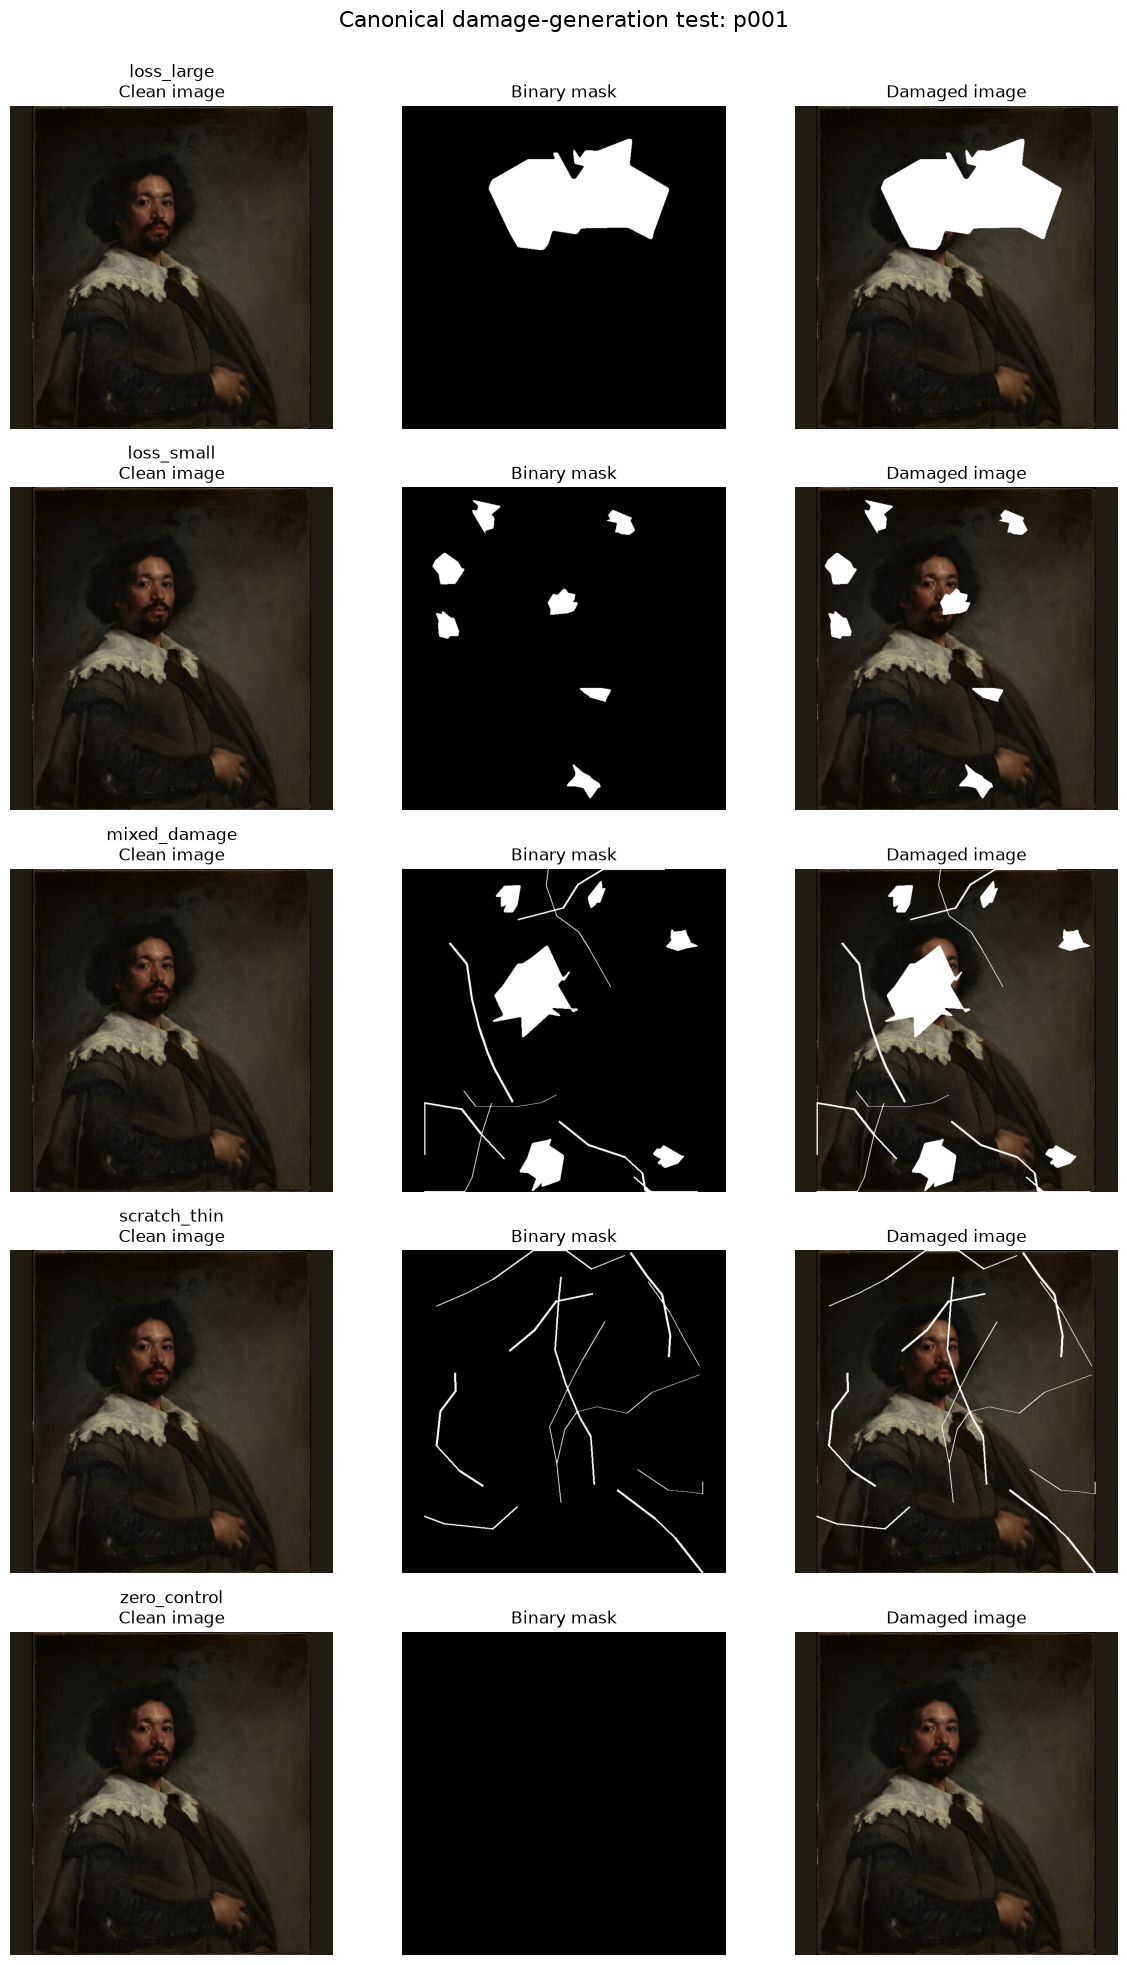

Saved test visualisation: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\figures\damage_creation\one_painting_damage_generation_test.png

Visual-inspection note: white regions indicate the synthetic damage fill. The corresponding mask remains the authoritative definition of the damaged region.


In [5]:
# Visual inspection of the one-painting test

test_visual_metadata_df = (
    test_damaged_metadata_df
    .sort_values(
        ["mask_type", "case_id"],
        kind="stable",
    )
    .reset_index(drop=True)
)

num_visual_cases = len(
    test_visual_metadata_df
)

figure, axes = plt.subplots(
    num_visual_cases,
    3,
    figsize=(12, 4 * num_visual_cases),
)

if num_visual_cases == 1:
    axes = np.expand_dims(
        axes,
        axis=0,
    )

for row_index, row in (
    test_visual_metadata_df.iterrows()
):
    clean_path = Path(
        row["clean_path"]
    )

    mask_path = Path(
        row["mask_path"]
    )

    damaged_path = Path(
        row["damaged_path"]
    )

    if not clean_path.is_absolute():
        clean_path = (
            PROJECT_ROOT / clean_path
        )

    if not mask_path.is_absolute():
        mask_path = (
            PROJECT_ROOT / mask_path
        )

    if not damaged_path.is_absolute():
        damaged_path = (
            PROJECT_ROOT / damaged_path
        )

    with Image.open(clean_path) as clean_image:
        clean_array = np.asarray(
            clean_image.convert("RGB")
        )

    with Image.open(mask_path) as mask_image:
        mask_array = np.asarray(
            mask_image.convert("L")
        )

    with Image.open(damaged_path) as damaged_image:
        damaged_array = np.asarray(
            damaged_image.convert("RGB")
        )

    axes[row_index, 0].imshow(
        clean_array
    )

    axes[row_index, 0].set_title(
        f"{row['mask_type']}\nClean image"
    )

    axes[row_index, 1].imshow(
        mask_array,
        cmap="gray",
        vmin=0,
        vmax=255,
    )

    axes[row_index, 1].set_title(
        "Binary mask"
    )

    axes[row_index, 2].imshow(
        damaged_array
    )

    axes[row_index, 2].set_title(
        "Damaged image"
    )

    for axis in axes[row_index]:
        axis.axis("off")

figure.suptitle(
    f"Canonical damage-generation test: "
    f"{test_painting_id}",
    fontsize=16,
)

figure.tight_layout(
    rect=[0, 0, 1, 0.98]
)

test_visualisation_path = (
    figures_dir
    / "one_painting_damage_generation_test.png"
)

figure.savefig(
    test_visualisation_path,
    dpi=200,
    bbox_inches="tight",
)

plt.show()
plt.close(figure)

print(
    "Saved test visualisation:",
    test_visualisation_path,
)

print(
    "\nVisual-inspection note: "
    "white regions indicate the synthetic damage fill. "
    "The corresponding mask remains the authoritative "
    "definition of the damaged region."
)

In [6]:
# Full canonical damaged-image generation

expected_case_ids = (
    mask_metadata_df[
        "case_id"
    ]
    .astype(str)
    .tolist()
)

expected_damaged_filenames = {
    f"{case_id}_damaged.png"
    for case_id in expected_case_ids
}

existing_damaged_files_before_generation = {
    path.name
    for path in damaged_dir.glob(
        "*_damaged.png"
    )
    if path.is_file()
}

stale_files_before_generation = sorted(
    existing_damaged_files_before_generation
    - expected_damaged_filenames
)

print(
    "Existing damaged files before generation:",
    len(existing_damaged_files_before_generation),
)

print(
    "Stale or orphaned damaged files before generation:",
    len(stale_files_before_generation),
)

if stale_files_before_generation:
    stale_file_preview_df = pd.DataFrame(
        {
            "damaged_filename": (
                stale_files_before_generation
            )
        }
    )

    display(
        stale_file_preview_df.head(20)
    )

    for stale_filename in (
        stale_files_before_generation
    ):
        stale_path = (
            damaged_dir / stale_filename
        )

        stale_path.unlink()

    print(
        "Removed stale damaged files:",
        len(stale_files_before_generation),
    )

generation_started_at_utc = datetime.now(
    timezone.utc
).isoformat()

damaged_metadata_df = (
    create_damaged_images_for_dataset(
        processed_metadata=(
            processed_metadata_df
        ),
        mask_metadata=(
            mask_metadata_df
        ),
        clean_dir=clean_dir,
        damaged_dir=damaged_dir,
        fill_color=damage_fill_color,
        fill_strategy=damage_fill_strategy,
        project_root=PROJECT_ROOT,
        overwrite=True,
        compute_checksums=True,
    )
)

generation_completed_at_utc = datetime.now(
    timezone.utc
).isoformat()

print(
    "Generated damaged-image metadata rows:",
    len(damaged_metadata_df),
)

print("\nGeneration status:")
display(
    damaged_metadata_df[
        "status"
    ]
    .value_counts(dropna=False)
    .rename_axis("status")
    .reset_index(name="count")
)

print("\nGeneration actions:")
display(
    damaged_metadata_df[
        "generation_action"
    ]
    .value_counts(dropna=False)
    .rename_axis("generation_action")
    .reset_index(name="count")
)

generation_error_rows = (
    damaged_metadata_df[
        damaged_metadata_df[
            "status"
        ]
        != "ok"
    ]
)

if not generation_error_rows.empty:
    display(
        generation_error_rows[
            [
                "case_id",
                "painting_id",
                "mask_type",
                "damaged_path",
                "status",
                "issue",
            ]
        ]
    )

    raise ValueError(
        "Full damaged-image generation "
        "produced one or more errors."
    )

if len(damaged_metadata_df) != expected_case_count:
    raise ValueError(
        "Unexpected damaged-image metadata row count: "
        f"observed={len(damaged_metadata_df)}, "
        f"expected={expected_case_count}"
    )

if (
    damaged_metadata_df[
        "case_id"
    ]
    .astype(str)
    .duplicated()
    .any()
):
    raise ValueError(
        "Generated damaged metadata contains "
        "duplicate case IDs."
    )

if (
    damaged_metadata_df[
        "damaged_filename"
    ]
    .astype(str)
    .duplicated()
    .any()
):
    raise ValueError(
        "Generated damaged metadata contains "
        "duplicate damaged filenames."
    )

generated_case_ids = set(
    damaged_metadata_df[
        "case_id"
    ].astype(str)
)

missing_generated_case_ids = sorted(
    set(expected_case_ids)
    - generated_case_ids
)

unexpected_generated_case_ids = sorted(
    generated_case_ids
    - set(expected_case_ids)
)

if missing_generated_case_ids:
    raise ValueError(
        "Expected mask cases are missing from "
        "damaged-image metadata: "
        f"{missing_generated_case_ids[:10]}"
    )

if unexpected_generated_case_ids:
    raise ValueError(
        "Unexpected cases were generated: "
        f"{unexpected_generated_case_ids[:10]}"
    )

required_generation_metadata_columns = [
    "generator_name",
    "generator_version",
    "generated_at_utc",
    "generation_action",
    "clean_path",
    "mask_path",
    "damaged_path",
    "damage_fill_strategy",
    "damage_fill_r",
    "damage_fill_g",
    "damage_fill_b",
    "width",
    "height",
    "mode",
    "format",
    "damaged_file_size_bytes",
    "clean_sha256",
    "mask_sha256",
    "damaged_sha256",
]

missing_generation_metadata_columns = [
    column
    for column in required_generation_metadata_columns
    if column not in damaged_metadata_df.columns
]

if missing_generation_metadata_columns:
    raise ValueError(
        "Generated damaged metadata is missing "
        "required provenance columns: "
        f"{missing_generation_metadata_columns}"
    )

null_provenance_counts = (
    damaged_metadata_df[
        required_generation_metadata_columns
    ]
    .isna()
    .sum()
)

invalid_null_provenance = (
    null_provenance_counts[
        null_provenance_counts > 0
    ]
)

if not invalid_null_provenance.empty:
    display(
        invalid_null_provenance
        .rename("null_count")
        .reset_index(
            names="column"
        )
    )

    raise ValueError(
        "Generated damaged metadata contains "
        "missing provenance values."
    )

print(
    "\nFull canonical damaged-image "
    "generation passed."
)

Existing damaged files before generation: 250
Stale or orphaned damaged files before generation: 0
Generated damaged-image metadata rows: 250

Generation status:


,status,count
0,ok,250



Generation actions:


,generation_action,count
0,generated,250



Full canonical damaged-image generation passed.


In [7]:
# Save canonical damaged-image metadata and verify reload

damaged_metadata_sort_columns = [
    "painting_id",
    "mask_type",
    "case_id",
]

damaged_metadata_df = (
    damaged_metadata_df
    .sort_values(
        damaged_metadata_sort_columns,
        kind="stable",
    )
    .reset_index(drop=True)
)

damaged_metadata_df.to_csv(
    damaged_metadata_path,
    index=False,
)

print(
    "Saved canonical damaged metadata:",
    damaged_metadata_path,
)

if not damaged_metadata_path.exists():
    raise FileNotFoundError(
        "Canonical damaged metadata was not "
        f"saved: {damaged_metadata_path}"
    )

reloaded_damaged_metadata_df = pd.read_csv(
    damaged_metadata_path
)

print(
    "Reloaded damaged metadata shape:",
    reloaded_damaged_metadata_df.shape,
)

if (
    reloaded_damaged_metadata_df.shape
    != damaged_metadata_df.shape
):
    raise ValueError(
        "Reloaded damaged metadata shape differs "
        "from the in-memory metadata shape."
    )

if (
    reloaded_damaged_metadata_df.columns.tolist()
    != damaged_metadata_df.columns.tolist()
):
    raise ValueError(
        "Reloaded damaged metadata columns differ "
        "from the saved in-memory metadata."
    )

original_case_ids = (
    damaged_metadata_df[
        "case_id"
    ]
    .astype(str)
    .tolist()
)

reloaded_case_ids = (
    reloaded_damaged_metadata_df[
        "case_id"
    ]
    .astype(str)
    .tolist()
)

if reloaded_case_ids != original_case_ids:
    raise ValueError(
        "Case order or case identifiers changed "
        "after metadata reload."
    )

metadata_reload_comparison_columns = [
    "case_id",
    "painting_id",
    "mask_id",
    "mask_type",
    "clean_filename",
    "clean_path",
    "mask_filename",
    "mask_path",
    "damaged_filename",
    "damaged_path",
    "damage_fill_strategy",
    "damage_fill_r",
    "damage_fill_g",
    "damage_fill_b",
    "damaged_area_pixels",
    "damaged_area_percentage_content",
    "damaged_area_percentage_full",
    "width",
    "height",
    "mode",
    "format",
    "damaged_file_size_bytes",
    "clean_sha256",
    "mask_sha256",
    "damaged_sha256",
    "status",
]

metadata_reload_mismatches = []

for column in metadata_reload_comparison_columns:
    original_values = (
        damaged_metadata_df[column]
        .fillna("<NA>")
        .astype(str)
        .tolist()
    )

    reloaded_values = (
        reloaded_damaged_metadata_df[column]
        .fillna("<NA>")
        .astype(str)
        .tolist()
    )

    if original_values != reloaded_values:
        metadata_reload_mismatches.append(
            column
        )

if metadata_reload_mismatches:
    raise ValueError(
        "Metadata values changed after CSV reload "
        "for columns: "
        f"{metadata_reload_mismatches}"
    )

damaged_metadata_df = (
    reloaded_damaged_metadata_df.copy()
)

print(
    "\nCanonical damaged metadata "
    "save-and-reload verification passed."
)

display(
    damaged_metadata_df.head()
)

Saved canonical damaged metadata: D:\Masters\FH\Thesis\painting-restoration-eval\data\processed\metadata\metadata_damaged_images.csv
Reloaded damaged metadata shape: (250, 31)

Canonical damaged metadata save-and-reload verification passed.


,case_id,painting_id,mask_id,mask_type,generator_name,generator_version,generated_at_utc,generation_action,clean_filename,clean_path,...,width,height,mode,format,damaged_file_size_bytes,clean_sha256,mask_sha256,damaged_sha256,status,issue
0,p001_loss_large,p001,p001_loss_large,loss_large,canonical_damage_generator,2.0.0,2026-07-23T08:50:15.038799+00:00,generated,p001_clean.png,data\processed\clean\p001_clean.png,...,768,768,RGB,PNG,631126,b5852f0337c8342a1a70268f9e9f682534177581d23871...,0c3aa0f9d930a7b8405439b8ec04e899f72bbe219472b0...,b7d7bd4dc2c427bc58c96a397bb24defe2f34945ad8114...,ok,NaN
1,p001_loss_small,p001,p001_loss_small,loss_small,canonical_damage_generator,2.0.0,2026-07-23T08:50:15.038799+00:00,generated,p001_clean.png,data\processed\clean\p001_clean.png,...,768,768,RGB,PNG,704339,b5852f0337c8342a1a70268f9e9f682534177581d23871...,3b1600dab63bd0ee34f019c51e988b02bb43cb193d8930...,d8cb0269b9074b0e596d3ef817ab3c98ec1838b06457dd...,ok,NaN
2,p001_mixed_damage,p001,p001_mixed_damage,mixed_damage,canonical_damage_generator,2.0.0,2026-07-23T08:50:15.038799+00:00,generated,p001_clean.png,data\processed\clean\p001_clean.png,...,768,768,RGB,PNG,675436,b5852f0337c8342a1a70268f9e9f682534177581d23871...,66aa435e3d05dd8f922f95a0065ef7b626192d8a1e9833...,e5a985ef19e47ab186d825692ca24efbea810c3bd1391a...,ok,NaN
3,p001_scratch_thin,p001,p001_scratch_thin,scratch_thin,canonical_damage_generator,2.0.0,2026-07-23T08:50:15.038799+00:00,generated,p001_clean.png,data\processed\clean\p001_clean.png,...,768,768,RGB,PNG,728164,b5852f0337c8342a1a70268f9e9f682534177581d23871...,14dc08421a7e8d5a5f8f96825a2161b6295cd41a98e48a...,7d2e0affa9d97493f34263767ed46cce8d5df73a74caa2...,ok,NaN
4,p001_zero_control,p001,p001_zero_control,zero_control,canonical_damage_generator,2.0.0,2026-07-23T08:50:15.038799+00:00,generated,p001_clean.png,data\processed\clean\p001_clean.png,...,768,768,RGB,PNG,723881,b5852f0337c8342a1a70268f9e9f682534177581d23871...,49e2b0f2e0dc8fe44017bdabfa19ff50311b0bdd176233...,b5852f0337c8342a1a70268f9e9f682534177581d23871...,ok,NaN


In [8]:
# Reloaded saved-file and pixel-level validation

damaged_file_validation_df = (
    validate_damaged_images(
        damaged_metadata=(
            damaged_metadata_df
        ),
        target_size=target_size,
        project_root=PROJECT_ROOT,
        verify_checksums=True,
    )
)

damage_application_validation_df = (
    validate_damage_application(
        damaged_metadata=(
            damaged_metadata_df
        ),
        target_size=target_size,
        project_root=PROJECT_ROOT,
        verify_source_checksums=True,
    )
)

print("Saved damaged-file validation:")
display(
    damaged_file_validation_df[
        "validation_passed"
    ]
    .value_counts(dropna=False)
    .rename_axis("validation_passed")
    .reset_index(name="count")
)

print("\nDamage-application validation:")
display(
    damage_application_validation_df[
        "validation_passed"
    ]
    .value_counts(dropna=False)
    .rename_axis("validation_passed")
    .reset_index(name="count")
)

failed_damaged_file_validation_df = (
    damaged_file_validation_df[
        ~damaged_file_validation_df[
            "validation_passed"
        ]
    ]
)

failed_damage_application_validation_df = (
    damage_application_validation_df[
        ~damage_application_validation_df[
            "validation_passed"
        ]
    ]
)

if not failed_damaged_file_validation_df.empty:
    print(
        "\nFailed damaged-file validation rows:"
    )

    display(
        failed_damaged_file_validation_df
    )

if not failed_damage_application_validation_df.empty:
    print(
        "\nFailed damage-application validation rows:"
    )

    display(
        failed_damage_application_validation_df
    )

file_validation_summary_df = pd.DataFrame(
    [
        {
            "check": "all_files_exist",
            "issue_count": int(
                (
                    ~damaged_file_validation_df[
                        "file_exists"
                    ]
                ).sum()
            ),
        },
        {
            "check": "all_files_readable",
            "issue_count": int(
                (
                    ~damaged_file_validation_df[
                        "readable"
                    ]
                ).sum()
            ),
        },
        {
            "check": "all_dimensions_correct",
            "issue_count": int(
                (
                    (
                        damaged_file_validation_df[
                            "width"
                        ]
                        != target_size
                    )
                    |
                    (
                        damaged_file_validation_df[
                            "height"
                        ]
                        != target_size
                    )
                ).sum()
            ),
        },
        {
            "check": "all_modes_rgb",
            "issue_count": int(
                (
                    damaged_file_validation_df[
                        "mode"
                    ]
                    != "RGB"
                ).sum()
            ),
        },
        {
            "check": "all_formats_png",
            "issue_count": int(
                (
                    damaged_file_validation_df[
                        "format"
                    ]
                    != "PNG"
                ).sum()
            ),
        },
        {
            "check": "all_filenames_match_metadata",
            "issue_count": int(
                (
                    ~damaged_file_validation_df[
                        "filename_matches_metadata"
                    ]
                ).sum()
            ),
        },
        {
            "check": "all_saved_checksums_match",
            "issue_count": int(
                damaged_file_validation_df[
                    "issue"
                ]
                .fillna("")
                .str.contains(
                    "sha256_mismatch",
                    regex=False,
                )
                .sum()
            ),
        },
    ]
)

file_validation_summary_df["passed"] = (
    file_validation_summary_df[
        "issue_count"
    ]
    == 0
)

application_validation_summary_df = pd.DataFrame(
    [
        {
            "check": "no_pixels_changed_outside_mask",
            "issue_count": int(
                (
                    damage_application_validation_df[
                        "outside_mask_changed_pixels"
                    ]
                    .fillna(-1)
                    != 0
                ).sum()
            ),
        },
        {
            "check": "all_mask_pixels_use_fill_colour",
            "issue_count": int(
                (
                    damage_application_validation_df[
                        "inside_mask_not_fill_pixels"
                    ]
                    .fillna(-1)
                    != 0
                ).sum()
            ),
        },
        {
            "check": "mask_pixel_counts_match_metadata",
            "issue_count": int(
                (
                    damage_application_validation_df[
                        "mask_pixel_count_difference"
                    ]
                    .fillna(-1)
                    != 0
                ).sum()
            ),
        },
        {
            "check": "changed_pixel_counts_are_consistent",
            "issue_count": int(
                (
                    damage_application_validation_df[
                        "changed_pixel_count_difference"
                    ]
                    .fillna(-1)
                    != 0
                ).sum()
            ),
        },
        {
            "check": "all_zero_controls_unchanged",
            "issue_count": int(
                (
                    (
                        damage_application_validation_df[
                            "mask_type"
                        ]
                        == "zero_control"
                    )
                    &
                    (
                        ~damage_application_validation_df[
                            "clean_equals_damaged"
                        ]
                        .fillna(False)
                    )
                ).sum()
            ),
        },
        {
            "check": "all_nonzero_masks_have_pixels",
            "issue_count": int(
                (
                    (
                        damage_application_validation_df[
                            "mask_type"
                        ]
                        != "zero_control"
                    )
                    &
                    (
                        damage_application_validation_df[
                            "total_mask_pixels"
                        ]
                        .fillna(0)
                        <= 0
                    )
                ).sum()
            ),
        },
        {
            "check": "source_checksums_match",
            "issue_count": int(
                damage_application_validation_df[
                    "issue"
                ]
                .fillna("")
                .str.contains(
                    "sha256_mismatch",
                    regex=False,
                )
                .sum()
            ),
        },
    ]
)

application_validation_summary_df[
    "passed"
] = (
    application_validation_summary_df[
        "issue_count"
    ]
    == 0
)

print("\nSaved-file validation summary:")
display(file_validation_summary_df)

print("\nApplication validation summary:")
display(application_validation_summary_df)

if not failed_damaged_file_validation_df.empty:
    raise ValueError(
        "One or more saved damaged-image "
        "files failed validation."
    )

if not failed_damage_application_validation_df.empty:
    raise ValueError(
        "One or more damaged images failed "
        "pixel-level application validation."
    )

print(
    "\nSaved-file and pixel-level "
    "validation passed."
)

Saved damaged-file validation:


,validation_passed,count
0,True,250



Damage-application validation:


,validation_passed,count
0,True,250



Saved-file validation summary:


,check,issue_count,passed
0,all_files_exist,0,True
1,all_files_readable,0,True
2,all_dimensions_correct,0,True
3,all_modes_rgb,0,True
4,all_formats_png,0,True
5,all_filenames_match_metadata,0,True
6,all_saved_checksums_match,0,True



Application validation summary:


,check,issue_count,passed
0,no_pixels_changed_outside_mask,0,True
1,all_mask_pixels_use_fill_colour,0,True
2,mask_pixel_counts_match_metadata,0,True
3,changed_pixel_counts_are_consistent,0,True
4,all_zero_controls_unchanged,0,True
5,all_nonzero_masks_have_pixels,0,True
6,source_checksums_match,0,True



Saved-file and pixel-level validation passed.


In [9]:
# Canonical damaged-image inventory audit

damaged_inventory_audit = (
    audit_damaged_inventory(
        damaged_metadata=(
            damaged_metadata_df
        ),
        damaged_dir=damaged_dir,
        expected_case_ids=(
            expected_case_ids
        ),
        filename_pattern="*_damaged.png",
        project_root=PROJECT_ROOT,
    )
)

damaged_inventory_summary_df = (
    damaged_inventory_audit[
        "summary"
    ].copy()
)

duplicate_damaged_case_rows_df = (
    damaged_inventory_audit[
        "duplicate_case_rows"
    ].copy()
)

duplicate_damaged_filename_rows_df = (
    damaged_inventory_audit[
        "duplicate_filename_rows"
    ].copy()
)

duplicate_damaged_path_rows_df = (
    damaged_inventory_audit[
        "duplicate_path_rows"
    ].copy()
)

missing_damaged_case_rows_df = (
    damaged_inventory_audit[
        "missing_case_rows"
    ].copy()
)

unexpected_damaged_case_rows_df = (
    damaged_inventory_audit[
        "unexpected_case_rows"
    ].copy()
)

missing_damaged_file_rows_df = (
    damaged_inventory_audit[
        "missing_file_rows"
    ].copy()
)

orphan_damaged_file_rows_df = (
    damaged_inventory_audit[
        "orphan_file_rows"
    ].copy()
)

damaged_filename_mismatch_rows_df = (
    damaged_inventory_audit[
        "filename_mismatch_rows"
    ].copy()
)

print("Damaged-image inventory audit:")
display(
    damaged_inventory_summary_df
)

audit_detail_tables = {
    "duplicate case rows": (
        duplicate_damaged_case_rows_df
    ),
    "duplicate filename rows": (
        duplicate_damaged_filename_rows_df
    ),
    "duplicate path rows": (
        duplicate_damaged_path_rows_df
    ),
    "missing expected cases": (
        missing_damaged_case_rows_df
    ),
    "unexpected metadata cases": (
        unexpected_damaged_case_rows_df
    ),
    "missing damaged files": (
        missing_damaged_file_rows_df
    ),
    "orphan damaged files": (
        orphan_damaged_file_rows_df
    ),
    "filename/path mismatches": (
        damaged_filename_mismatch_rows_df
    ),
}

for table_name, detail_df in (
    audit_detail_tables.items()
):
    if not detail_df.empty:
        print(f"\n{table_name}:")
        display(detail_df.head(20))

failed_inventory_checks_df = (
    damaged_inventory_summary_df[
        ~damaged_inventory_summary_df[
            "passed"
        ]
    ]
)

disk_damaged_file_count = len(
    [
        path
        for path in damaged_dir.glob(
            "*_damaged.png"
        )
        if path.is_file()
    ]
)

print(
    "\nExpected damaged files:",
    expected_case_count,
)

print(
    "Metadata damaged-image rows:",
    len(damaged_metadata_df),
)

print(
    "Damaged files on disk:",
    disk_damaged_file_count,
)

if (
    disk_damaged_file_count
    != expected_case_count
):
    raise ValueError(
        "Damaged-image file count differs from "
        "the expected canonical case count."
    )

if not failed_inventory_checks_df.empty:
    display(
        failed_inventory_checks_df
    )

    raise ValueError(
        "Canonical damaged-image inventory "
        "audit failed."
    )

print(
    "\nCanonical damaged-image "
    "inventory audit passed."
)

Damaged-image inventory audit:


,check,issue_count,passed
0,duplicate_case_ids,0,True
1,duplicate_damaged_filenames,0,True
2,duplicate_damaged_paths,0,True
3,missing_expected_case_ids,0,True
4,unexpected_metadata_case_ids,0,True
5,missing_damaged_files,0,True
6,orphan_damaged_files,0,True
7,filename_path_consistency,0,True



Expected damaged files: 250
Metadata damaged-image rows: 250
Damaged files on disk: 250

Canonical damaged-image inventory audit passed.


In [10]:
# Canonical damage-generation summary tables

damage_case_summary_df = (
    damaged_metadata_df
    .groupby(
        "mask_type",
        sort=False,
    )
    .agg(
        case_count=("case_id", "count"),
        painting_count=(
            "painting_id",
            "nunique",
        ),
        total_damaged_pixels=(
            "damaged_area_pixels",
            "sum",
        ),
        mean_damaged_pixels=(
            "damaged_area_pixels",
            "mean",
        ),
        median_damaged_pixels=(
            "damaged_area_pixels",
            "median",
        ),
        min_damaged_pixels=(
            "damaged_area_pixels",
            "min",
        ),
        max_damaged_pixels=(
            "damaged_area_pixels",
            "max",
        ),
        mean_damage_percentage_content=(
            "damaged_area_percentage_content",
            "mean",
        ),
        median_damage_percentage_content=(
            "damaged_area_percentage_content",
            "median",
        ),
        mean_damage_percentage_full=(
            "damaged_area_percentage_full",
            "mean",
        ),
        total_file_size_bytes=(
            "damaged_file_size_bytes",
            "sum",
        ),
        mean_file_size_bytes=(
            "damaged_file_size_bytes",
            "mean",
        ),
    )
    .reindex(expected_mask_types)
    .reset_index()
)

damage_case_summary_df[
    "mean_damaged_pixels"
] = (
    damage_case_summary_df[
        "mean_damaged_pixels"
    ]
    .round(2)
)

damage_case_summary_df[
    "median_damaged_pixels"
] = (
    damage_case_summary_df[
        "median_damaged_pixels"
    ]
    .round(2)
)

damage_case_summary_df[
    "mean_damage_percentage_content"
] = (
    damage_case_summary_df[
        "mean_damage_percentage_content"
    ]
    .round(4)
)

damage_case_summary_df[
    "median_damage_percentage_content"
] = (
    damage_case_summary_df[
        "median_damage_percentage_content"
    ]
    .round(4)
)

damage_case_summary_df[
    "mean_damage_percentage_full"
] = (
    damage_case_summary_df[
        "mean_damage_percentage_full"
    ]
    .round(4)
)

damage_case_summary_df[
    "mean_file_size_bytes"
] = (
    damage_case_summary_df[
        "mean_file_size_bytes"
    ]
    .round(2)
)

pixel_change_summary_df = (
    damage_application_validation_df
    .groupby(
        "mask_type",
        sort=False,
    )
    .agg(
        case_count=("case_id", "count"),
        total_mask_pixels=(
            "total_mask_pixels",
            "sum",
        ),
        total_changed_pixels=(
            "changed_pixel_count",
            "sum",
        ),
        total_already_fill_pixels=(
            "unchanged_mask_pixel_count",
            "sum",
        ),
        total_outside_mask_changes=(
            "outside_mask_changed_pixels",
            "sum",
        ),
        total_inside_mask_fill_failures=(
            "inside_mask_not_fill_pixels",
            "sum",
        ),
        mean_changed_pixels=(
            "changed_pixel_count",
            "mean",
        ),
        mean_already_fill_pixels=(
            "unchanged_mask_pixel_count",
            "mean",
        ),
    )
    .reindex(expected_mask_types)
    .reset_index()
)

pixel_change_summary_df[
    "mean_changed_pixels"
] = (
    pixel_change_summary_df[
        "mean_changed_pixels"
    ]
    .round(2)
)

pixel_change_summary_df[
    "mean_already_fill_pixels"
] = (
    pixel_change_summary_df[
        "mean_already_fill_pixels"
    ]
    .round(2)
)

pixel_change_summary_df[
    "observed_change_rate_within_mask"
] = np.where(
    pixel_change_summary_df[
        "total_mask_pixels"
    ]
    > 0,
    (
        pixel_change_summary_df[
            "total_changed_pixels"
        ]
        /
        pixel_change_summary_df[
            "total_mask_pixels"
        ]
    ),
    0.0,
)

pixel_change_summary_df[
    "observed_change_rate_within_mask"
] = (
    pixel_change_summary_df[
        "observed_change_rate_within_mask"
    ]
    .round(6)
)

generation_provenance_summary_df = pd.DataFrame(
    [
        {
            "field": "generator_name",
            "value": GENERATOR_NAME,
        },
        {
            "field": "generator_version",
            "value": GENERATOR_VERSION,
        },
        {
            "field": "generation_started_at_utc",
            "value": generation_started_at_utc,
        },
        {
            "field": "generation_completed_at_utc",
            "value": generation_completed_at_utc,
        },
        {
            "field": "fill_strategy",
            "value": damage_fill_strategy,
        },
        {
            "field": "fill_colour_rgb",
            "value": str(
                tuple(damage_fill_color)
            ),
        },
        {
            "field": "target_size",
            "value": str(target_size),
        },
        {
            "field": "painting_count",
            "value": str(
                damaged_metadata_df[
                    "painting_id"
                ].nunique()
            ),
        },
        {
            "field": "damage_case_count",
            "value": str(
                len(damaged_metadata_df)
            ),
        },
        {
            "field": "damaged_file_count",
            "value": str(
                disk_damaged_file_count
            ),
        },
        {
            "field": "stale_files_removed",
            "value": str(
                len(
                    stale_files_before_generation
                )
            ),
        },
    ]
)

print("Damage-case summary:")
display(damage_case_summary_df)

print("\nPixel-change summary:")
display(pixel_change_summary_df)

print("\nGeneration provenance summary:")
display(generation_provenance_summary_df)

Damage-case summary:


,mask_type,case_count,painting_count,total_damaged_pixels,mean_damaged_pixels,median_damaged_pixels,min_damaged_pixels,max_damaged_pixels,mean_damage_percentage_content,median_damage_percentage_content,mean_damage_percentage_full,total_file_size_bytes,mean_file_size_bytes
0,zero_control,50,50,0,0.00,0.0,0,0,0.0000,0.0000,0.0000,36126399,722527.98
1,scratch_thin,50,50,480723,9614.46,9433.0,6085,15664,2.1363,2.1380,1.6301,36293710,725874.20
2,loss_small,50,50,908768,18175.36,18344.5,12394,25311,4.0246,3.9334,3.0815,34974053,699481.06
3,loss_large,50,50,2811849,56236.98,54922.0,37439,83018,12.3288,12.2767,9.5345,31844524,636890.48
4,mixed_damage,50,50,2171000,43420.00,42955.5,34209,52887,9.6600,9.3117,7.3615,33708068,674161.36



Pixel-change summary:


,mask_type,case_count,total_mask_pixels,total_changed_pixels,total_already_fill_pixels,total_outside_mask_changes,total_inside_mask_fill_failures,mean_changed_pixels,mean_already_fill_pixels,observed_change_rate_within_mask
0,zero_control,50,0,0,0,0,0,0.00,0.00,0.000000
1,scratch_thin,50,480723,480723,0,0,0,9614.46,0.00,1.000000
2,loss_small,50,908768,908765,3,0,0,18175.30,0.06,0.999997
3,loss_large,50,2811849,2811842,7,0,0,56236.84,0.14,0.999998
4,mixed_damage,50,2171000,2170998,2,0,0,43419.96,0.04,0.999999



Generation provenance summary:


,field,value
0,generator_name,canonical_damage_generator
1,generator_version,2.0.0
2,generation_started_at_utc,2026-07-23T08:50:15.038799+00:00
3,generation_completed_at_utc,2026-07-23T08:51:47.885282+00:00
4,fill_strategy,white_fill
5,fill_colour_rgb,"(255, 255, 255)"
6,target_size,768
7,painting_count,50
8,damage_case_count,250
9,damaged_file_count,250


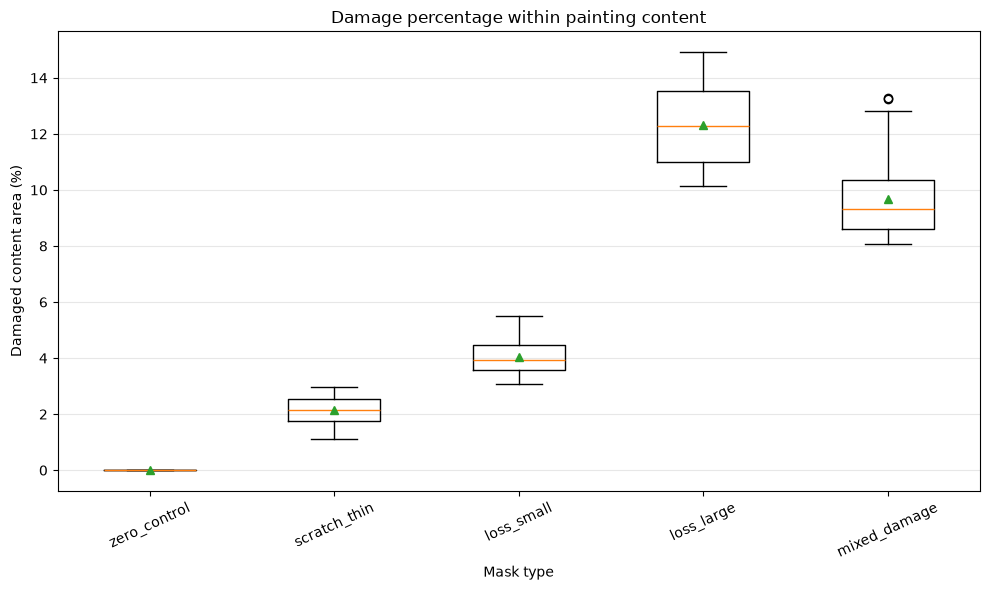

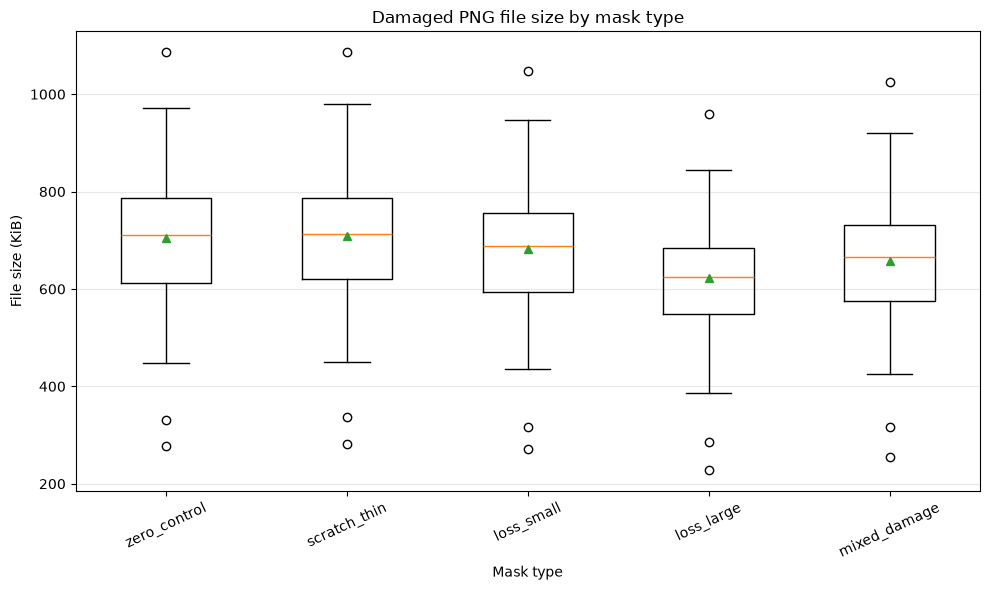

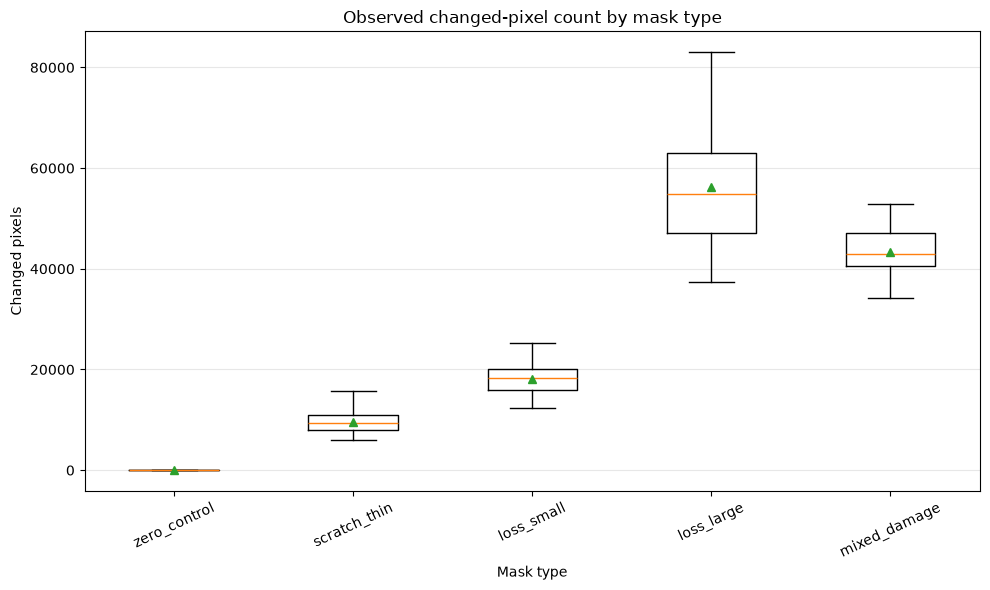

Saved figures:
D:\Masters\FH\Thesis\painting-restoration-eval\outputs\figures\damage_creation\damage_percentage_by_mask_type.png
D:\Masters\FH\Thesis\painting-restoration-eval\outputs\figures\damage_creation\damaged_file_size_by_mask_type.png
D:\Masters\FH\Thesis\painting-restoration-eval\outputs\figures\damage_creation\changed_pixels_by_mask_type.png


In [13]:
# Publication-quality damage-generation figures

damage_percentage_figure_path = (
    figures_dir
    / "damage_percentage_by_mask_type.png"
)

file_size_figure_path = (
    figures_dir
    / "damaged_file_size_by_mask_type.png"
)

changed_pixel_figure_path = (
    figures_dir
    / "changed_pixels_by_mask_type.png"
)

damage_plot_df = (
    damaged_metadata_df
    .copy()
)

damage_plot_df[
    "mask_type"
] = pd.Categorical(
    damage_plot_df["mask_type"],
    categories=expected_mask_types,
    ordered=True,
)

damage_plot_df = (
    damage_plot_df
    .sort_values(
        ["mask_type", "painting_id"],
        kind="stable",
    )
)

figure, axis = plt.subplots(
    figsize=(10, 6)
)

damage_groups = [
    damage_plot_df.loc[
        damage_plot_df["mask_type"]
        == mask_type,
        "damaged_area_percentage_content",
    ].to_numpy()
    for mask_type in expected_mask_types
]

axis.boxplot(
    damage_groups,
    tick_labels=expected_mask_types,
    showmeans=True,
)

axis.set_title(
    "Damage percentage within painting content"
)

axis.set_xlabel("Mask type")

axis.set_ylabel(
    "Damaged content area (%)"
)

axis.tick_params(
    axis="x",
    rotation=25,
)

axis.grid(
    axis="y",
    alpha=0.3,
)

figure.tight_layout()

figure.savefig(
    damage_percentage_figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()
plt.close(figure)

figure, axis = plt.subplots(
    figsize=(10, 6)
)

file_size_groups = [
    (
        damage_plot_df.loc[
            damage_plot_df["mask_type"]
            == mask_type,
            "damaged_file_size_bytes",
        ]
        .to_numpy()
        / 1024
    )
    for mask_type in expected_mask_types
]

axis.boxplot(
    file_size_groups,
    tick_labels=expected_mask_types,
    showmeans=True,
)

axis.set_title(
    "Damaged PNG file size by mask type"
)

axis.set_xlabel("Mask type")

axis.set_ylabel("File size (KiB)")

axis.tick_params(
    axis="x",
    rotation=25,
)

axis.grid(
    axis="y",
    alpha=0.3,
)

figure.tight_layout()

figure.savefig(
    file_size_figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()
plt.close(figure)

change_plot_df = (
    damage_application_validation_df
    .copy()
)

change_plot_df[
    "mask_type"
] = pd.Categorical(
    change_plot_df["mask_type"],
    categories=expected_mask_types,
    ordered=True,
)

change_plot_df = (
    change_plot_df
    .sort_values(
        ["mask_type", "painting_id"],
        kind="stable",
    )
)

figure, axis = plt.subplots(
    figsize=(10, 6)
)

changed_pixel_groups = [
    change_plot_df.loc[
        change_plot_df["mask_type"]
        == mask_type,
        "changed_pixel_count",
    ].to_numpy()
    for mask_type in expected_mask_types
]

axis.boxplot(
    changed_pixel_groups,
    tick_labels=expected_mask_types,
    showmeans=True,
)

axis.set_title(
    "Observed changed-pixel count by mask type"
)

axis.set_xlabel("Mask type")

axis.set_ylabel("Changed pixels")

axis.tick_params(
    axis="x",
    rotation=25,
)

axis.grid(
    axis="y",
    alpha=0.3,
)

figure.tight_layout()

figure.savefig(
    changed_pixel_figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()
plt.close(figure)

print("Saved figures:")

print(
    damage_percentage_figure_path
)

print(
    file_size_figure_path
)

print(
    changed_pixel_figure_path
)

In [14]:
# Export canonical damage-generation audit artefacts

damage_case_summary_path = (
    metrics_dir
    / "damage_case_summary.csv"
)

pixel_change_summary_path = (
    metrics_dir
    / "damage_pixel_change_summary.csv"
)

file_validation_path = (
    metrics_dir
    / "damage_file_validation.csv"
)

application_validation_path = (
    metrics_dir
    / "damage_application_validation.csv"
)

file_validation_summary_path = (
    metrics_dir
    / "damage_file_validation_summary.csv"
)

application_validation_summary_path = (
    metrics_dir
    / "damage_application_validation_summary.csv"
)

inventory_summary_path = (
    metrics_dir
    / "damage_inventory_audit_summary.csv"
)

provenance_summary_path = (
    metrics_dir
    / "damage_generation_provenance.csv"
)

damage_manifest_path = (
    reports_dir
    / "damage_generation_manifest.json"
)

damage_report_path = (
    reports_dir
    / "damage_generation_report.md"
)

damage_case_summary_df.to_csv(
    damage_case_summary_path,
    index=False,
)

pixel_change_summary_df.to_csv(
    pixel_change_summary_path,
    index=False,
)

damaged_file_validation_df.to_csv(
    file_validation_path,
    index=False,
)

damage_application_validation_df.to_csv(
    application_validation_path,
    index=False,
)

file_validation_summary_df.to_csv(
    file_validation_summary_path,
    index=False,
)

application_validation_summary_df.to_csv(
    application_validation_summary_path,
    index=False,
)

damaged_inventory_summary_df.to_csv(
    inventory_summary_path,
    index=False,
)

generation_provenance_summary_df.to_csv(
    provenance_summary_path,
    index=False,
)

detail_export_map = {
    (
        metrics_dir
        / "damage_inventory_duplicate_cases.csv"
    ): duplicate_damaged_case_rows_df,
    (
        metrics_dir
        / "damage_inventory_duplicate_filenames.csv"
    ): duplicate_damaged_filename_rows_df,
    (
        metrics_dir
        / "damage_inventory_duplicate_paths.csv"
    ): duplicate_damaged_path_rows_df,
    (
        metrics_dir
        / "damage_inventory_missing_cases.csv"
    ): missing_damaged_case_rows_df,
    (
        metrics_dir
        / "damage_inventory_unexpected_cases.csv"
    ): unexpected_damaged_case_rows_df,
    (
        metrics_dir
        / "damage_inventory_missing_files.csv"
    ): missing_damaged_file_rows_df,
    (
        metrics_dir
        / "damage_inventory_orphan_files.csv"
    ): orphan_damaged_file_rows_df,
    (
        metrics_dir
        / "damage_inventory_filename_mismatches.csv"
    ): damaged_filename_mismatch_rows_df,
}

for export_path, export_df in (
    detail_export_map.items()
):
    export_df.to_csv(
        export_path,
        index=False,
    )

manifest = {
    "notebook": (
        "04_damage_creation_cleaned.ipynb"
    ),
    "stage": (
        "canonical_damaged_image_generation"
    ),
    "generator": {
        "name": GENERATOR_NAME,
        "version": GENERATOR_VERSION,
    },
    "generation": {
        "started_at_utc": (
            generation_started_at_utc
        ),
        "completed_at_utc": (
            generation_completed_at_utc
        ),
        "fill_strategy": (
            damage_fill_strategy
        ),
        "fill_colour_rgb": list(
            damage_fill_color
        ),
        "target_size": target_size,
        "overwrite": True,
        "checksums_enabled": True,
    },
    "counts": {
        "expected_paintings": (
            expected_painting_count
        ),
        "observed_paintings": int(
            damaged_metadata_df[
                "painting_id"
            ].nunique()
        ),
        "expected_mask_types": (
            expected_mask_type_count
        ),
        "observed_mask_types": int(
            damaged_metadata_df[
                "mask_type"
            ].nunique()
        ),
        "expected_cases": (
            expected_case_count
        ),
        "metadata_cases": int(
            len(damaged_metadata_df)
        ),
        "files_on_disk": int(
            disk_damaged_file_count
        ),
        "stale_files_removed": int(
            len(
                stale_files_before_generation
            )
        ),
    },
    "validation": {
        "file_validation_passed": bool(
            damaged_file_validation_df[
                "validation_passed"
            ].all()
        ),
        "application_validation_passed": bool(
            damage_application_validation_df[
                "validation_passed"
            ].all()
        ),
        "inventory_validation_passed": bool(
            damaged_inventory_summary_df[
                "passed"
            ].all()
        ),
        "outside_mask_changed_pixels": int(
            damage_application_validation_df[
                "outside_mask_changed_pixels"
            ].sum()
        ),
        "inside_mask_fill_failures": int(
            damage_application_validation_df[
                "inside_mask_not_fill_pixels"
            ].sum()
        ),
        "mask_pixel_count_difference": int(
            damage_application_validation_df[
                "mask_pixel_count_difference"
            ].sum()
        ),
        "changed_pixel_count_difference": int(
            damage_application_validation_df[
                "changed_pixel_count_difference"
            ].sum()
        ),
    },
    "paths": {
        "processed_metadata": str(
            processed_metadata_path.relative_to(
                PROJECT_ROOT
            )
        ),
        "mask_metadata": str(
            mask_metadata_path.relative_to(
                PROJECT_ROOT
            )
        ),
        "damaged_metadata": str(
            damaged_metadata_path.relative_to(
                PROJECT_ROOT
            )
        ),
        "clean_directory": str(
            clean_dir.relative_to(
                PROJECT_ROOT
            )
        ),
        "damaged_directory": str(
            damaged_dir.relative_to(
                PROJECT_ROOT
            )
        ),
    },
    "mask_types": expected_mask_types,
    "summary_records": (
        damage_case_summary_df
        .to_dict(orient="records")
    ),
}

with damage_manifest_path.open(
    "w",
    encoding="utf-8",
) as manifest_file:
    json.dump(
        manifest,
        manifest_file,
        indent=2,
    )

report_lines = [
    "# Canonical Damaged-Image Generation Report",
    "",
    (
        "This report documents the synthetic "
        "damage-generation stage for the "
        "50-painting controlled evaluation subset."
    ),
    "",
    "## Generation settings",
    "",
    f"- Generator: `{GENERATOR_NAME}`",
    (
        f"- Generator version: "
        f"`{GENERATOR_VERSION}`"
    ),
    (
        f"- Fill strategy: "
        f"`{damage_fill_strategy}`"
    ),
    (
        f"- Fill colour: "
        f"`{tuple(damage_fill_color)}`"
    ),
    f"- Target dimensions: {target_size} × {target_size}",
    (
        f"- Paintings: "
        f"{damaged_metadata_df['painting_id'].nunique()}"
    ),
    (
        f"- Damage cases: "
        f"{len(damaged_metadata_df)}"
    ),
    "",
    "## Mask conditions",
    "",
]

for mask_type in expected_mask_types:
    mask_row = (
        damage_case_summary_df[
            damage_case_summary_df[
                "mask_type"
            ]
            == mask_type
        ]
    )

    if mask_row.empty:
        continue

    summary_row = mask_row.iloc[0]

    report_lines.append(
        (
            f"- `{mask_type}`: "
            f"{int(summary_row['case_count'])} cases, "
            f"mean damaged content area "
            f"{summary_row['mean_damage_percentage_content']:.4f}%"
        )
    )

report_lines.extend(
    [
        "",
        "## Validation result",
        "",
        (
            "- All damaged images were reloaded "
            "successfully as RGB PNG files with "
            f"{target_size} × {target_size} dimensions."
        ),
        (
            "- No pixels outside the binary masks "
            "were changed."
        ),
        (
            "- Every masked output pixel matched "
            "the configured fill colour."
        ),
        (
            "- Mask-pixel counts matched canonical "
            "mask metadata."
        ),
        (
            "- Zero-control outputs remained "
            "identical to their clean source images."
        ),
        (
            "- Clean, mask, and damaged-image "
            "SHA-256 checksums were recorded."
        ),
        (
            "- Inventory auditing found no missing, "
            "duplicate, unexpected, or orphaned "
            "damaged-image files."
        ),
        "",
        "## Output provenance",
        "",
        (
            f"- Canonical metadata: "
            f"`{damaged_metadata_path.relative_to(PROJECT_ROOT)}`"
        ),
        (
            f"- Damaged images: "
            f"`{damaged_dir.relative_to(PROJECT_ROOT)}`"
        ),
        (
            f"- Validation tables: "
            f"`{metrics_dir.relative_to(PROJECT_ROOT)}`"
        ),
        (
            f"- Figures: "
            f"`{figures_dir.relative_to(PROJECT_ROOT)}`"
        ),
        "",
        "## Interpretation note",
        "",
        (
            "The number of numerically changed pixels "
            "may be slightly lower than the number of "
            "masked pixels when a clean source pixel "
            "already equals the white fill colour. "
            "This does not represent a generation "
            "failure. The authoritative conditions "
            "are exact preservation outside the mask "
            "and correct fill values inside it."
        ),
    ]
)

damage_report_path.write_text(
    "\n".join(report_lines),
    encoding="utf-8",
)

exported_paths = [
    damaged_metadata_path,
    damage_case_summary_path,
    pixel_change_summary_path,
    file_validation_path,
    application_validation_path,
    file_validation_summary_path,
    application_validation_summary_path,
    inventory_summary_path,
    provenance_summary_path,
    damage_manifest_path,
    damage_report_path,
    damage_percentage_figure_path,
    file_size_figure_path,
    changed_pixel_figure_path,
    test_visualisation_path,
    *detail_export_map.keys(),
]

missing_exported_paths = [
    path
    for path in exported_paths
    if not path.exists()
]

if missing_exported_paths:
    raise FileNotFoundError(
        "One or more damage-generation exports "
        "were not created: "
        f"{missing_exported_paths}"
    )

print("Exported canonical damage artefacts:")

for exported_path in exported_paths:
    print(
        "-",
        exported_path.relative_to(
            PROJECT_ROOT
        ),
    )

Exported canonical damage artefacts:
- data\processed\metadata\metadata_damaged_images.csv
- outputs\metrics\damage_case_summary.csv
- outputs\metrics\damage_pixel_change_summary.csv
- outputs\metrics\damage_file_validation.csv
- outputs\metrics\damage_application_validation.csv
- outputs\metrics\damage_file_validation_summary.csv
- outputs\metrics\damage_application_validation_summary.csv
- outputs\metrics\damage_inventory_audit_summary.csv
- outputs\metrics\damage_generation_provenance.csv
- outputs\reports\damage_generation_manifest.json
- outputs\reports\damage_generation_report.md
- outputs\figures\damage_creation\damage_percentage_by_mask_type.png
- outputs\figures\damage_creation\damaged_file_size_by_mask_type.png
- outputs\figures\damage_creation\changed_pixels_by_mask_type.png
- outputs\figures\damage_creation\one_painting_damage_generation_test.png
- outputs\metrics\damage_inventory_duplicate_cases.csv
- outputs\metrics\damage_inventory_duplicate_filenames.csv
- outputs\metri

In [15]:
# Final canonical damaged-image generation audit

final_audit_rows = [
    {
        "check": "expected_metadata_rows",
        "observed": len(
            damaged_metadata_df
        ),
        "expected": expected_case_count,
        "passed": (
            len(damaged_metadata_df)
            == expected_case_count
        ),
    },
    {
        "check": "expected_unique_paintings",
        "observed": int(
            damaged_metadata_df[
                "painting_id"
            ].nunique()
        ),
        "expected": expected_painting_count,
        "passed": (
            damaged_metadata_df[
                "painting_id"
            ].nunique()
            == expected_painting_count
        ),
    },
    {
        "check": "expected_unique_mask_types",
        "observed": int(
            damaged_metadata_df[
                "mask_type"
            ].nunique()
        ),
        "expected": expected_mask_type_count,
        "passed": (
            damaged_metadata_df[
                "mask_type"
            ].nunique()
            == expected_mask_type_count
        ),
    },
    {
        "check": "expected_files_on_disk",
        "observed": disk_damaged_file_count,
        "expected": expected_case_count,
        "passed": (
            disk_damaged_file_count
            == expected_case_count
        ),
    },
    {
        "check": "all_generation_status_ok",
        "observed": int(
            (
                damaged_metadata_df[
                    "status"
                ]
                != "ok"
            ).sum()
        ),
        "expected": 0,
        "passed": (
            damaged_metadata_df[
                "status"
            ]
            .eq("ok")
            .all()
        ),
    },
    {
        "check": "all_saved_files_valid",
        "observed": int(
            (
                ~damaged_file_validation_df[
                    "validation_passed"
                ]
            ).sum()
        ),
        "expected": 0,
        "passed": bool(
            damaged_file_validation_df[
                "validation_passed"
            ].all()
        ),
    },
    {
        "check": "all_damage_applications_valid",
        "observed": int(
            (
                ~damage_application_validation_df[
                    "validation_passed"
                ]
            ).sum()
        ),
        "expected": 0,
        "passed": bool(
            damage_application_validation_df[
                "validation_passed"
            ].all()
        ),
    },
    {
        "check": "all_inventory_checks_pass",
        "observed": int(
            (
                ~damaged_inventory_summary_df[
                    "passed"
                ]
            ).sum()
        ),
        "expected": 0,
        "passed": bool(
            damaged_inventory_summary_df[
                "passed"
            ].all()
        ),
    },
    {
        "check": "outside_mask_changes",
        "observed": int(
            damage_application_validation_df[
                "outside_mask_changed_pixels"
            ].sum()
        ),
        "expected": 0,
        "passed": (
            damage_application_validation_df[
                "outside_mask_changed_pixels"
            ].sum()
            == 0
        ),
    },
    {
        "check": "inside_mask_fill_failures",
        "observed": int(
            damage_application_validation_df[
                "inside_mask_not_fill_pixels"
            ].sum()
        ),
        "expected": 0,
        "passed": (
            damage_application_validation_df[
                "inside_mask_not_fill_pixels"
            ].sum()
            == 0
        ),
    },
    {
        "check": "mask_pixel_count_difference",
        "observed": int(
            damage_application_validation_df[
                "mask_pixel_count_difference"
            ].abs().sum()
        ),
        "expected": 0,
        "passed": (
            damage_application_validation_df[
                "mask_pixel_count_difference"
            ].abs().sum()
            == 0
        ),
    },
    {
        "check": "changed_pixel_count_difference",
        "observed": int(
            damage_application_validation_df[
                "changed_pixel_count_difference"
            ].abs().sum()
        ),
        "expected": 0,
        "passed": (
            damage_application_validation_df[
                "changed_pixel_count_difference"
            ].abs().sum()
            == 0
        ),
    },
    {
        "check": "all_checksums_present",
        "observed": int(
            damaged_metadata_df[
                [
                    "clean_sha256",
                    "mask_sha256",
                    "damaged_sha256",
                ]
            ]
            .isna()
            .sum()
            .sum()
        ),
        "expected": 0,
        "passed": (
            damaged_metadata_df[
                [
                    "clean_sha256",
                    "mask_sha256",
                    "damaged_sha256",
                ]
            ]
            .notna()
            .all()
            .all()
        ),
    },
    {
        "check": "all_required_exports_exist",
        "observed": len(
            missing_exported_paths
        ),
        "expected": 0,
        "passed": (
            len(
                missing_exported_paths
            )
            == 0
        ),
    },
]

final_damage_audit_df = pd.DataFrame(
    final_audit_rows
)

final_damage_audit_path = (
    metrics_dir
    / "damage_generation_final_audit.csv"
)

final_damage_audit_df.to_csv(
    final_damage_audit_path,
    index=False,
)

print("Final damage-generation audit:")
display(final_damage_audit_df)

failed_final_audit_df = (
    final_damage_audit_df[
        ~final_damage_audit_df[
            "passed"
        ]
    ]
)

if not failed_final_audit_df.empty:
    display(
        failed_final_audit_df
    )

    raise ValueError(
        "Final canonical damaged-image "
        "generation audit failed."
    )

if test_damaged_dir.exists():
    shutil.rmtree(
        test_damaged_dir
    )

if test_damaged_dir.exists():
    raise RuntimeError(
        "Temporary one-painting test "
        "directory was not removed."
    )

print(
    "\nTemporary test outputs removed."
)

print(
    "\nNotebook 04 canonical damaged-image "
    "generation completed successfully."
)

Final damage-generation audit:


,check,observed,expected,passed
0,expected_metadata_rows,250,250,True
1,expected_unique_paintings,50,50,True
2,expected_unique_mask_types,5,5,True
3,expected_files_on_disk,250,250,True
4,all_generation_status_ok,0,0,True
5,all_saved_files_valid,0,0,True
6,all_damage_applications_valid,0,0,True
7,all_inventory_checks_pass,0,0,True
8,outside_mask_changes,0,0,True
9,inside_mask_fill_failures,0,0,True



Temporary test outputs removed.

Notebook 04 canonical damaged-image generation completed successfully.


## Damaged-image generation result

The 50-painting controlled subset now contains one canonical damaged image for every mask case:

- `zero_control`
- `scratch_thin`
- `loss_small`
- `loss_large`
- `mixed_damage`

This produced **250 damaged RGB PNG images**.

Each damaged image was created using a white-fill strategy in which only pixels marked by the corresponding binary mask were replaced. Validation confirmed that no unmasked pixels changed, every masked output pixel used the configured fill colour, mask-pixel counts matched the canonical mask metadata, and zero-control images remained identical to their clean sources.

All outputs were reloaded and checked for dimensions, colour mode, PNG format, filename consistency, file size, and SHA-256 checksum integrity. The inventory audit found no missing, duplicate, unexpected, stale, or orphaned damaged-image files.

The canonical `metadata_damaged_images.csv` file records the clean-image, mask, and damaged-image paths together with fill settings, dimensions, file metadata, damaged-area measurements, generation provenance, and checksums.